In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("train.csv")
print("Original Shape:", df.shape)

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

print("Numeric Shape:", df.shape)

# Fill numeric missing values
df.fillna(df.mean(), inplace=True)

# Remove Id column
X = df.drop(["SalePrice", "Id"], axis=1)
y = df["SalePrice"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso
lasso = Lasso(alpha=0.01, max_iter=200000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Results
print("\nMODEL PERFORMANCE")
print("---------------------------")
print("Linear R2 :", r2_score(y_test, y_pred_lr))
print("Ridge R2  :", r2_score(y_test, y_pred_ridge))
print("Lasso R2  :", r2_score(y_test, y_pred_lasso))

print("\nLinear MSE :", mean_squared_error(y_test, y_pred_lr))
print("Ridge MSE  :", mean_squared_error(y_test, y_pred_ridge))
print("Lasso MSE  :", mean_squared_error(y_test, y_pred_lasso))

print("\nExperiment Completed Successfully ✅")

Original Shape: (1460, 81)
Numeric Shape: (1460, 38)

MODEL PERFORMANCE
---------------------------
Linear R2 : 0.8231505934287373
Ridge R2  : 0.8231591194131878
Lasso R2  : 0.8231505955401445

Linear MSE : 1356492637.949047
Ridge MSE  : 1356427240.8670752
Lasso MSE  : 1356492621.7538655

Experiment Completed Successfully ✅


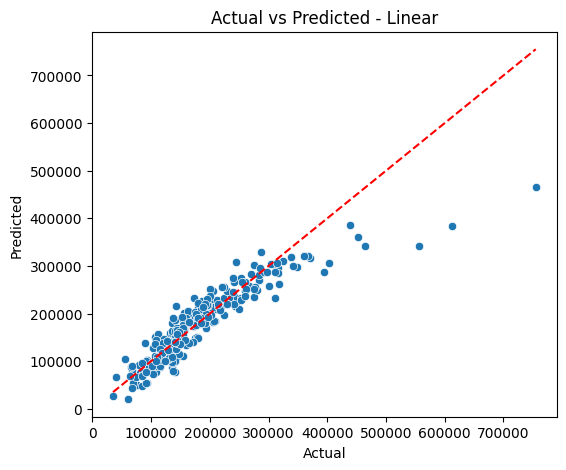

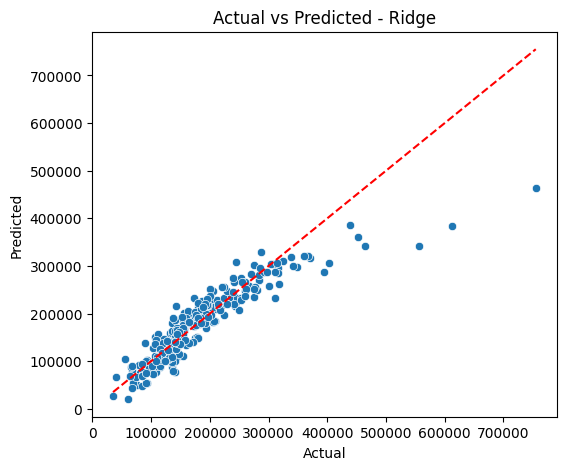

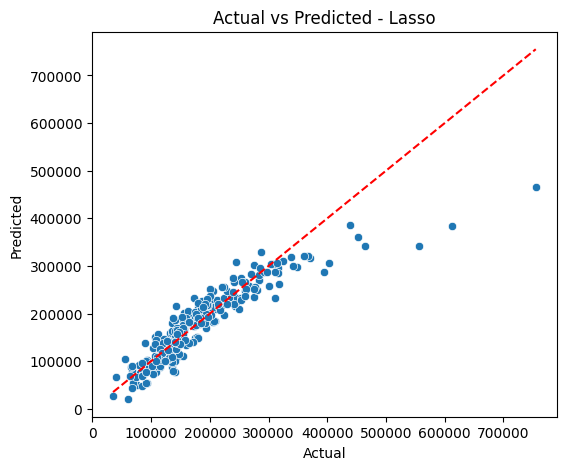

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Linear": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso
}

for name, preds in models.items():
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_test, y=preds)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
    plt.title(f"Actual vs Predicted - {name}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()